# Demo of learning GNN-derived gene embeddings on CPDB network.

This notebook provides a pipeline for learning GNN-derived gene embeddings on PPI networks.

In [13]:
import os
import copy
import time
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn import metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

import dgl
from dgl.dataloading import GraphDataLoader

import dataset, model
from train import FocalLoss
from train import (
    calculate_cluster_labels,
    visualize_embeddings_tsne,
    visualize_embeddings_pca,
    create_heatmap_with_stid,
    plot_cosine_similarity_matrix_for_clusters_with_values,
    draw_loss_plot,
    draw_f1_plot,
    draw_max_f1_plot
)


In [14]:
hyperparams = {
    "num_epochs": 100,
    "in_feats": 20,
    "out_feats": 300,
    "num_layers": 2,
    "num_heads": 2,
    "lr": 1e-3,
    "batch_size": 1,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

data_path = "data/emb"
plot = True

CLUSTER_COLORS = {
    0:  '#0077B6',  1:  '#0000FF',  2:  '#00B4D8',  3:  '#48EAC4',
    4:  '#F1C0E8',  5:  '#B9FBC0',  6:  '#32CD32',  7:  '#bee1e6',
    8:  '#8A2BE2',  9:  '#E377C2', 10: '#8EECF5', 11: '#A3C4F3',
    12: '#FFB347', 13: '#FFD700', 14: '#FF69B4', 15: '#CD5C5C',
    16: '#7FFFD4', 17: '#FF7F50', 18: '#C71585', 19: '#20B2AA',
    20: '#48CAE4', 21: '#90DBF4', 22: '#0077B6', 23: '#00B4D8',
    24: '#6A5ACD', 25: '#66CDAA', 26: '#FF8C00', 27: '#9370DB'
}

In [15]:
num_epochs = hyperparams["num_epochs"]
in_feats = hyperparams["in_feats"]
out_feats = hyperparams["out_feats"]
num_layers = hyperparams["num_layers"]
num_heads = hyperparams["num_heads"]
learning_rate = hyperparams["lr"]
batch_size = hyperparams["batch_size"]
device = hyperparams["device"]

model_dir = os.path.join(data_path, "models")
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir, f"model_dim{out_feats}_lay{num_layers}_epo{num_epochs}.pth"
)

ds = dataset.Dataset(data_path)
dl_train = GraphDataLoader([ds[0]], batch_size=batch_size, shuffle=True)
dl_valid = GraphDataLoader([ds[1]], batch_size=batch_size, shuffle=False)


In [16]:
net = model.TAGCNModel(
    dim_latent=out_feats,
    num_layers=num_layers,
    do_train=True
).to(device)

best_model = model.TAGCNModel(
    dim_latent=out_feats,
    num_layers=num_layers,
    do_train=True
)

optimizer = optim.Adam(net.parameters(), lr=learning_rate)

criterion = FocalLoss(alpha=0.25, gamma=2.0, reduction="mean")
weight = torch.tensor([0.00001, 0.99999]).to(device)


In [17]:
results_path = "results/multiomics_meth/node_embeddings/"
os.makedirs(results_path, exist_ok=True)

all_embeddings_initial, cluster_labels_initial = calculate_cluster_labels(
    best_model, dl_train, device
)
all_embeddings_initial = all_embeddings_initial.reshape(
    all_embeddings_initial.shape[0], -1
)


In [18]:
for graph, _ in dl_train:
    node_emb = best_model.get_node_embeddings(graph).detach().cpu().numpy()

    nx_graph = pickle.load(open(os.path.join(data_path, "raw/emb_train.pkl"), "rb"))
    node_to_index = {n: i for i, n in enumerate(nx_graph.nodes)}

    stid_embeddings = {
        nx_graph.nodes[n]["stId"]: node_emb[node_to_index[n]]
        for n in nx_graph.nodes if "stId" in nx_graph.nodes[n]
    }

    pd.DataFrame.from_dict(stid_embeddings, orient="index").to_csv(
        f"data/multiomics_meth/ppi_embeddings_lr{learning_rate}_dim{out_feats}_initial.csv",
        index_label="stId"
    )

    break


In [19]:
loss_per_epoch_train, loss_per_epoch_valid = [], []
f1_per_epoch_train, f1_per_epoch_valid = [], []
max_f1_scores_train, max_f1_scores_valid = [], []

best_valid_loss = float("inf")

with tqdm(total=num_epochs, desc="Training", unit="epoch") as pbar:
    for epoch in range(num_epochs):
        net.train()
        losses, f1s = [], []

        for graph, _ in dl_train:
            logits = net(graph)
            labels = graph.ndata["significance"].unsqueeze(-1)

            loss = criterion(logits, labels)
            preds = (logits.sigmoid() > 0.5).int()
            f1 = metrics.f1_score(labels.squeeze(1).int(), preds)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            f1s.append(f1)

        loss_per_epoch_train.append(np.mean(losses))
        f1_per_epoch_train.append(np.mean(f1s))

        pbar.update(1)


Training: 100%|██████████| 100/100 [01:35<00:00,  1.05epoch/s]


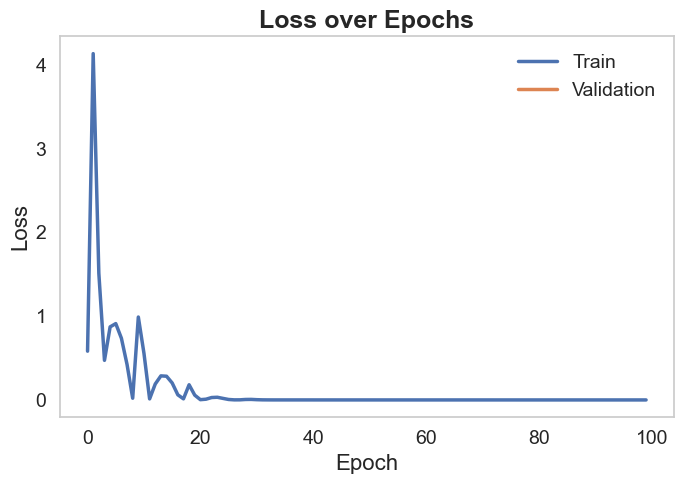

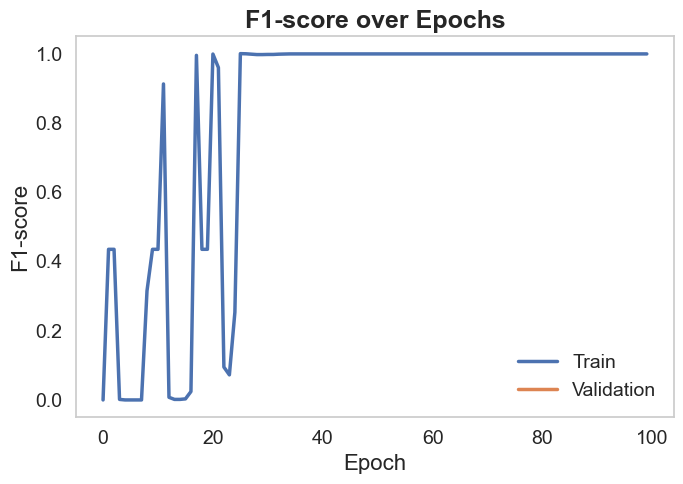

In [20]:
draw_loss_plot(
    loss_per_epoch_train,
    loss_per_epoch_valid,
    os.path.join(results_path, "loss.png")
)

draw_f1_plot(
    f1_per_epoch_train,
    f1_per_epoch_valid,
    os.path.join(results_path, "f1.png")
)


In [21]:
first_node_stId_in_cluster_initial = {}
first_node_embedding_in_cluster_initial = {}

for data in dl_train:
    graph, _ = data
    node_embeddings_initial = (
        best_model.get_node_embeddings(graph)
        .detach().cpu().numpy()
    )

    nx_graph = pickle.load(
        open(os.path.join(data_path, "raw/emb_train.pkl"), "rb")
    )

    node_to_index = {n: i for i, n in enumerate(nx_graph.nodes)}

    for node, cluster in zip(nx_graph.nodes, cluster_labels_initial):
        if "stId" not in nx_graph.nodes[node]:
            continue

        if cluster not in first_node_stId_in_cluster_initial:
            first_node_stId_in_cluster_initial[cluster] = nx_graph.nodes[node]["stId"]
            first_node_embedding_in_cluster_initial[cluster] = \
                node_embeddings_initial[node_to_index[node]]

    break


In [34]:

all_embeddings_initial, cluster_labels_initial = calculate_cluster_labels(best_model, dl_train, device)
all_embeddings_initial = all_embeddings_initial.reshape(all_embeddings_initial.shape[0], -1)  # Flatten 
save_path_heatmap_initial= os.path.join(results_path, f'ppi_embeddings_heatmap_stId_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
save_path_matrix_initial= os.path.join(results_path, f'ppi_embeddings_matrix_stId_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
save_path_pca_initial = os.path.join(results_path, f'ppi_embeddings_pca_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
save_path_t_SNE_initial = os.path.join(results_path, f'ppi_embeddings_t-SNE_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')


In [23]:
def plot_embedding_with_cluster_legend(
    embeddings_2d,
    cluster_labels,
    cluster_to_stid,
    title,
    xlabel,
    ylabel,
    save_path
):
    plt.figure(figsize=(10, 8))

    unique_clusters = np.unique(cluster_labels)

    for cluster_id in unique_clusters:
        idx = np.where(cluster_labels == cluster_id)[0]

        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            s=12,
            color=CLUSTER_COLORS[int(cluster_id)],  # ✅ fixed cluster color
            alpha=0.85,
            label=cluster_to_stid.get(
                cluster_id, f"Cluster {cluster_id}"
            )
        )

    # ---- Styling ----
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)
    plt.title(title, fontsize=18)

    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    plt.legend(
        title="Label",
        title_fontsize=14,
        fontsize=12,
        markerscale=2.2,          # larger legend dots
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.grid(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()



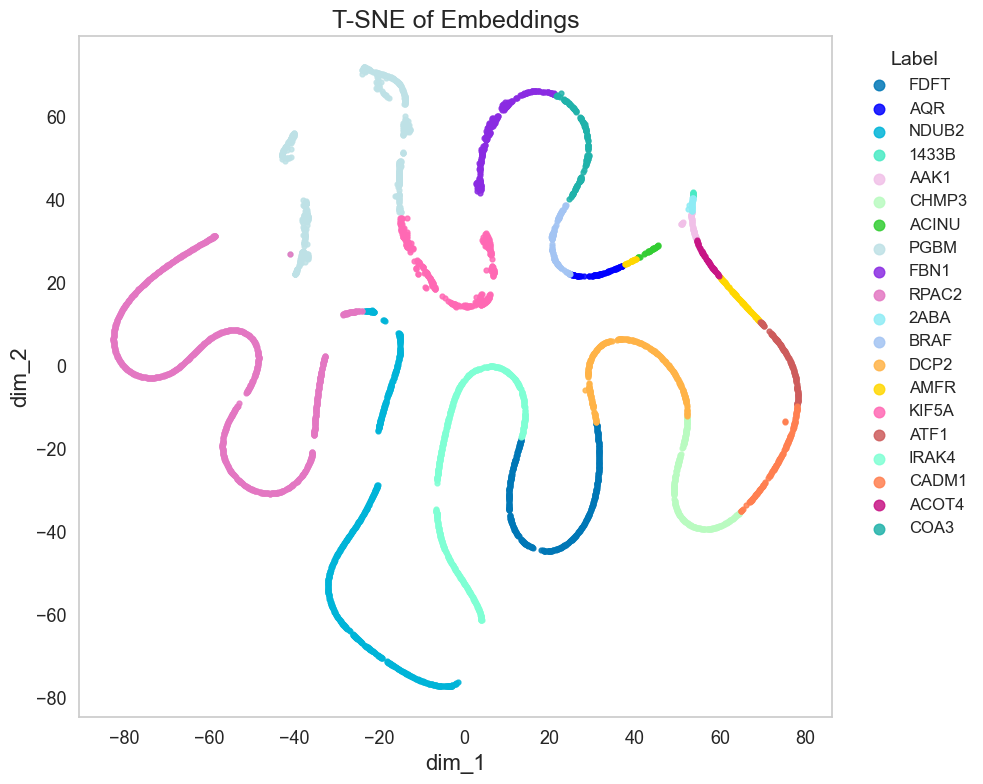

In [24]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    init="pca"
)

embeddings_tsne = tsne.fit_transform(all_embeddings_initial)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_tsne,
    cluster_labels=cluster_labels_initial,
    cluster_to_stid=first_node_stId_in_cluster_initial,
    title="T-SNE of Embeddings",
    xlabel="dim_1",
    ylabel="dim_2",
    save_path=save_path_t_SNE_initial
)


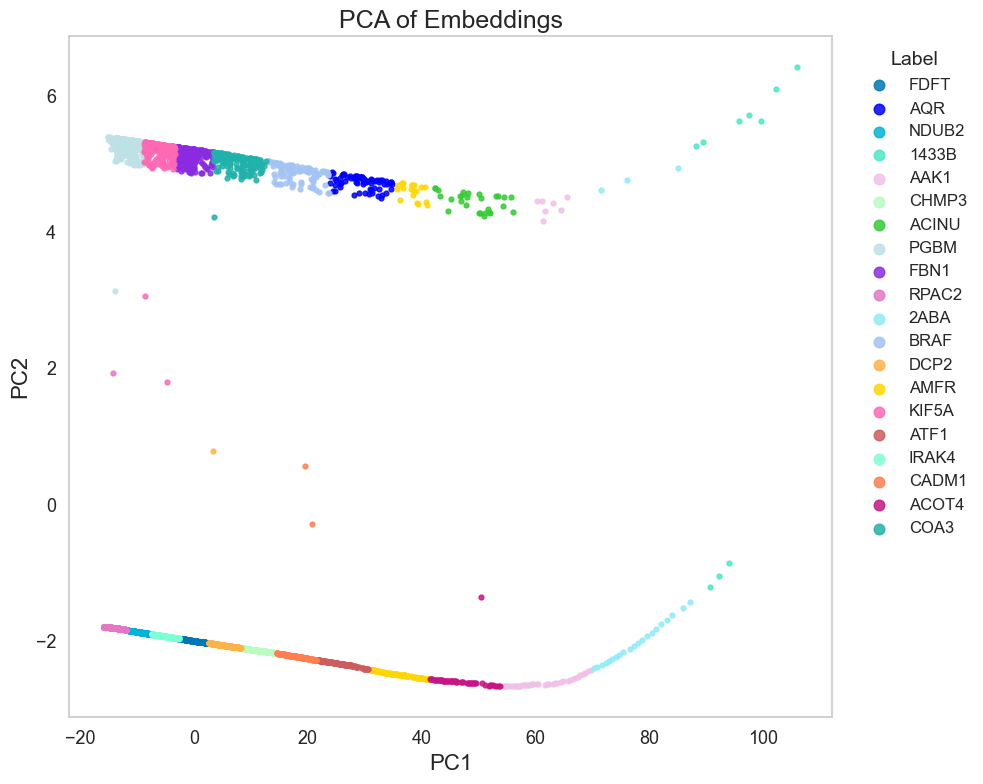

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(all_embeddings_initial)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_pca,
    cluster_labels=cluster_labels_initial,
    cluster_to_stid=first_node_stId_in_cluster_initial,
    title="PCA of Embeddings",
    xlabel="PC1",
    ylabel="PC2",
    save_path=save_path_pca_initial
)


/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


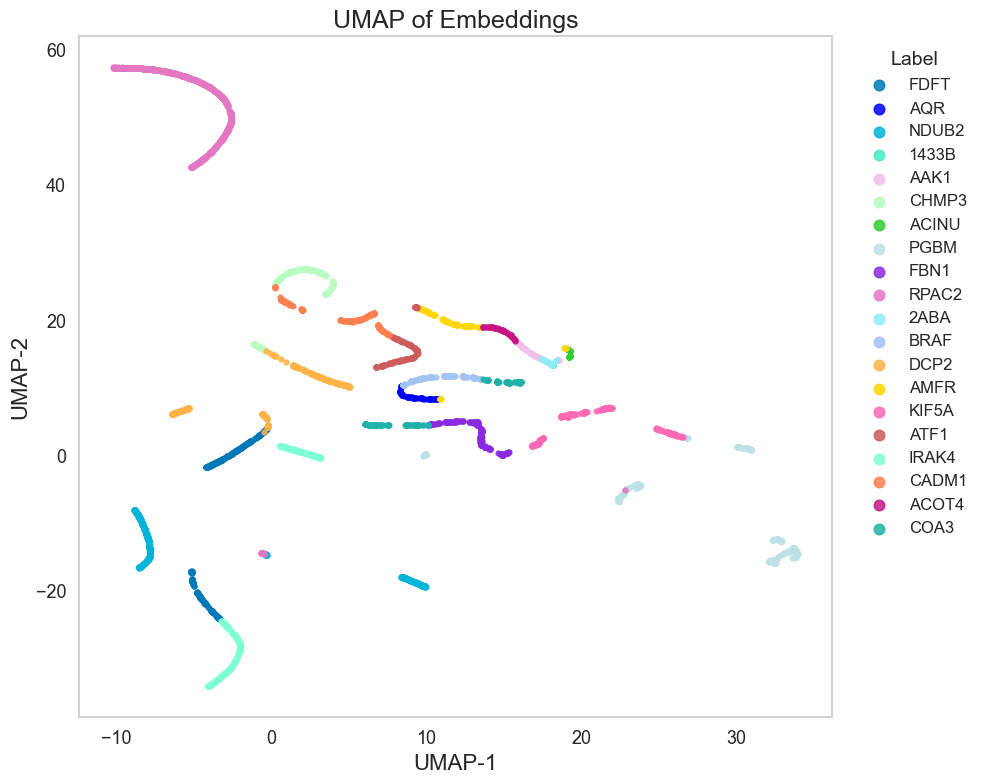

In [26]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embeddings_umap = umap_model.fit_transform(all_embeddings_initial)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_umap,
    cluster_labels=cluster_labels_initial,
    cluster_to_stid=first_node_stId_in_cluster_initial,
    title="UMAP of Embeddings",
    xlabel="UMAP-1",
    ylabel="UMAP-2",
    save_path=os.path.join(results_path, "ppi_embeddings_umap_initial.png")
)


In [27]:
def annotate_cluster_centroids(embeddings_2d, cluster_labels, cluster_to_stid):
    """
    Annotate each cluster using the centroid of its points.

    embeddings_2d : np.ndarray (N, 2)
    cluster_labels : np.ndarray (N,)
    cluster_to_stid : dict {cluster_id: stId}
    """
    for cluster_id, stid in cluster_to_stid.items():
        idx = np.where(cluster_labels == cluster_id)[0]
        if len(idx) == 0:
            continue

        centroid = embeddings_2d[idx].mean(axis=0)

        plt.text(
            centroid[0],
            centroid[1],
            stid,
            fontsize=8,
            weight="bold",
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )



In [31]:
all_embeddings_initial, cluster_labels_initial = calculate_cluster_labels(
    best_model, dl_train, device
)

all_embeddings_initial = all_embeddings_initial.reshape(
    all_embeddings_initial.shape[0], -1
)


In [32]:
first_node_stId_in_cluster_initial = {}
first_node_embedding_in_cluster_initial = {}

for data in dl_train:
    graph, _ = data
    node_embeddings_initial = (
        best_model.get_node_embeddings(graph)
        .detach().cpu().numpy()
    )

    nx_graph = pickle.load(
        open(os.path.join(data_path, "raw/emb_train.pkl"), "rb")
    )

    node_to_index = {n: i for i, n in enumerate(nx_graph.nodes)}

    for node, cluster in zip(nx_graph.nodes, cluster_labels_initial):
        if "stId" not in nx_graph.nodes[node]:
            continue

        if cluster not in first_node_stId_in_cluster_initial:
            first_node_stId_in_cluster_initial[cluster] = nx_graph.nodes[node]["stId"]
            first_node_embedding_in_cluster_initial[cluster] = \
                node_embeddings_initial[node_to_index[node]]

    break


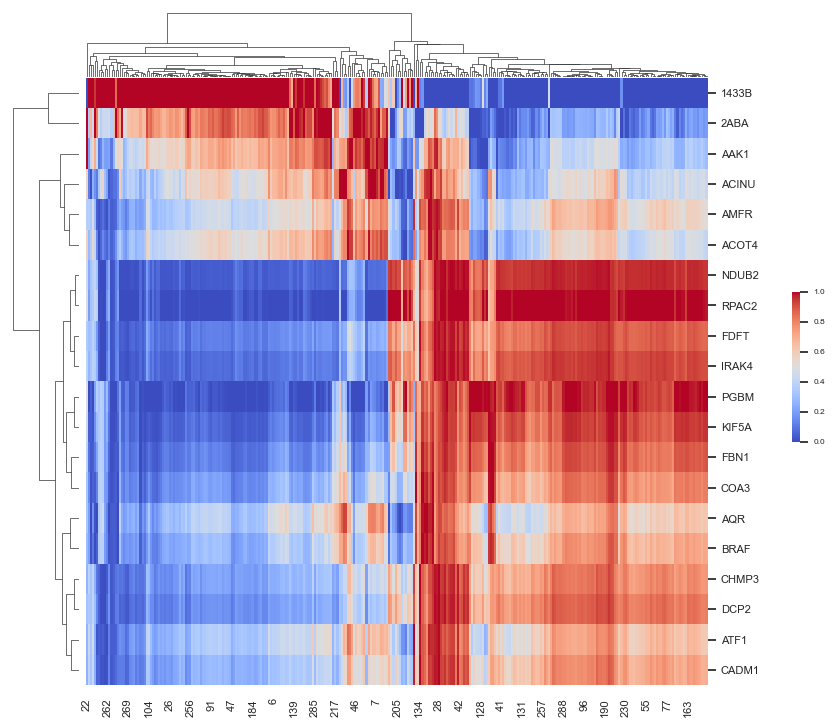

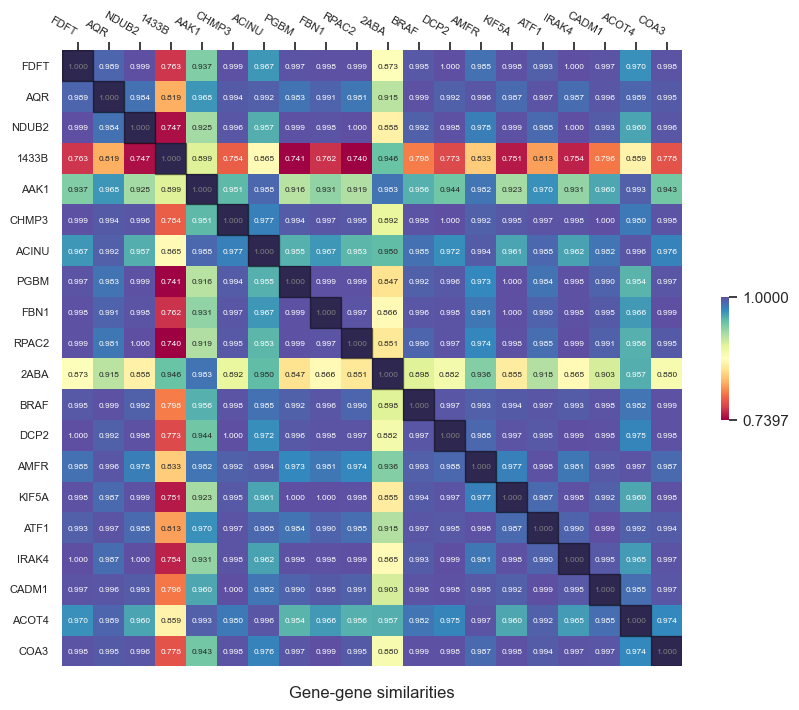

In [33]:
stid_list = [
    first_node_stId_in_cluster_initial[c]
    for c in sorted(first_node_stId_in_cluster_initial)
]

embedding_list = [
    first_node_embedding_in_cluster_initial[c]
    for c in sorted(first_node_embedding_in_cluster_initial)
]

create_heatmap_with_stid(
    embedding_list,
    stid_list,
    save_path_heatmap_initial
)

plot_cosine_similarity_matrix_for_clusters_with_values(
    embedding_list,
    stid_list,
    save_path_matrix_initial
)
